# Phase 10 — Out-of-time validation

Every result so far rests on a **random** train/test split, and the write-up
has listed that as the project's biggest weakness. Credit models are not used
that way. A lender trains on loans already originated and applies the model to
applicants arriving next quarter. Performance is therefore measured
**out-of-time**: train on older vintages, test on newer ones.

A random split leaks the future into the past. Loans from the same month sit
on both sides of it, sharing an economic environment, a credit policy and a
borrower mix. The model gets credit for conditions it would not know about in
production.

The original extract had no origination date, so this could not be done. This
notebook uses a dated Lending Club extract (396,030 loans, 2007–2016) to
answer the question the project has been dodging:

> **How much did the random split flatter the model?**

In [1]:
import warnings
from pathlib import Path

import lightgbm as lgb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.model_selection import train_test_split

warnings.filterwarnings("ignore")

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
FIGS = ROOT / "outputs" / "figures"
FIGS.mkdir(parents=True, exist_ok=True)

pd.set_option("display.width", 140)
pd.set_option("display.max_columns", 60)
sns.set_theme(style="whitegrid", palette="deep")
RANDOM_STATE = 42

raw = pd.read_csv(ROOT / "data" / "lending_club_dated.csv")
print(f"{raw.shape[0]:,} rows x {raw.shape[1]} columns")

396,030 rows x 27 columns


## 10.1 Rebuilding the features on dated data

Same engineering philosophy as Phase 3, applied to a richer file. Two things
are new.

**`grade` and `sub_grade` are excluded alongside `int_rate`.** This extract
carries Lending Club's internal risk grade directly. It is the *output of
their risk model*, which makes it even more blatant leakage than the interest
rate derived from it. Anyone training on this file without dropping `grade`
will report a spectacular AUC that means nothing.

**Six characteristics the original extract did not have** are available:
`installment`, `open_acc`, `pub_rec`, `revol_bal`, `mort_acc` and
`pub_rec_bankruptcies`.

In [2]:
df = pd.DataFrame(index=raw.index)

df["issue_dt"] = pd.to_datetime(raw.issue_d, format="%b-%Y")
df["vintage_year"] = df.issue_dt.dt.year
df["bad_loan"] = (raw.loan_status == "Charged Off").astype(int)

df["loan_amnt"] = raw.loan_amnt
df["term_months"] = raw.term.str.extract(r"(\d+)").astype(int)
df["annual_inc"] = raw.annual_inc
df["dti"] = raw.dti
df["revol_util"] = raw.revol_util
df["total_acc"] = raw.total_acc
df["open_acc"] = raw.open_acc
df["pub_rec"] = raw.pub_rec
df["revol_bal"] = raw.revol_bal
df["mort_acc"] = raw.mort_acc
df["pub_rec_bankruptcies"] = raw.pub_rec_bankruptcies
df["installment"] = raw.installment

# emp_length: "10+ years" -> 10, "< 1 year" -> 0, missing stays missing
emp = raw.emp_length.str.extract(r"(\d+)")[0].astype(float)
emp[raw.emp_length == "< 1 year"] = 0
df["emp_length"] = emp
df["emp_length_missing"] = raw.emp_length.isna().astype(int)

# Credit history length, in years at the moment of application
earliest = pd.to_datetime(raw.earliest_cr_line, format="%b-%Y", errors="coerce")
df["longest_credit_length"] = ((df.issue_dt - earliest).dt.days / 365.25).round(1)

df["home_ownership"] = raw.home_ownership.str.upper().replace(
    {"NONE": "OTHER", "ANY": "OTHER"})
df["purpose"] = raw.purpose.str.upper()
df["verification_status"] = raw.verification_status.str.upper()
# State sits at the end of the (synthetic) address, before the ZIP
df["addr_state"] = raw.address.str.extract(r"([A-Z]{2})\s+\d{5}\s*$")[0]

# The Phase 3 engineered features
df["loan_to_income"] = df.loan_amnt / df.annual_inc
df["payment_to_income"] = df.installment / (df.annual_inc / 12)
df["log_annual_inc"] = np.log10(df.annual_inc.clip(lower=1))
df["acct_open_rate"] = df.total_acc / (df.longest_credit_length + 1)
df["has_delinquency"] = (df.pub_rec > 0).astype(float)
df["over_limit"] = (df.revol_util > 100).astype(float)

CENSUS_REGION = {
    "NORTHEAST": ["CT", "ME", "MA", "NH", "RI", "VT", "NJ", "NY", "PA"],
    "MIDWEST": ["IL", "IN", "MI", "OH", "WI", "IA", "KS", "MN", "MO", "NE", "ND", "SD"],
    "SOUTH": ["DE", "FL", "GA", "MD", "NC", "SC", "VA", "DC", "WV", "AL", "KY",
              "MS", "TN", "AR", "LA", "OK", "TX"],
    "WEST": ["AZ", "CO", "ID", "MT", "NV", "NM", "UT", "WY", "AK", "CA", "HI", "OR", "WA"],
}
state_to_region = {s: r for r, states in CENSUS_REGION.items() for s in states}
df["region"] = df.addr_state.map(state_to_region).fillna("UNKNOWN")

print(f"Built {df.shape[1]} columns")
print(f"Overall default rate: {df.bad_loan.mean():.2%}")
print(f"State parsed for {df.addr_state.notna().mean():.1%} of rows")

Built 29 columns
Overall default rate: 19.61%
State parsed for 100.0% of rows


## 10.2 Vintage analysis — and a trap in the data

Before splitting on time, look at how the default rate moves by origination
year. This is the chart a credit risk team looks at first.

In [3]:
vintage = df.groupby("vintage_year").agg(
    loans=("bad_loan", "size"), bad_rate=("bad_loan", "mean"))
vintage["bad_rate_%"] = (vintage.bad_rate * 100).round(2)
print(vintage[["loans", "bad_rate_%"]].to_string())

               loans  bad_rate_%
vintage_year                    
2007             195       16.41
2008            1240       15.81
2009            3826       12.26
2010            9258       13.21
2011           17435       15.25
2012           41202       16.48
2013           97662       15.74
2014          102860       23.11
2015           94264       24.90
2016           28088       13.13


**2016 reports 13.1%, against 24.9% in 2015.** Credit quality did not almost
double in one year. This is an artefact, and it is the kind of thing that
quietly ruins an out-of-time study.

The file contains only **resolved** loans — every row is either `Fully Paid`
or `Charged Off`. A loan issued in 2016 only appears if it had already
finished by the time the data was collected. Loans that resolve fastest are
disproportionately early payoffs, so recent vintages are skewed toward good
outcomes.

This is the **incomplete performance window** problem. Real scorecard
development handles it by fixing a performance window — typically 18 to 24
months after origination — and excluding vintages too young to have one.

**2016 is therefore dropped.** Using it as the test set would produce a
flattering result driven entirely by which loans had finished, not by the
model.

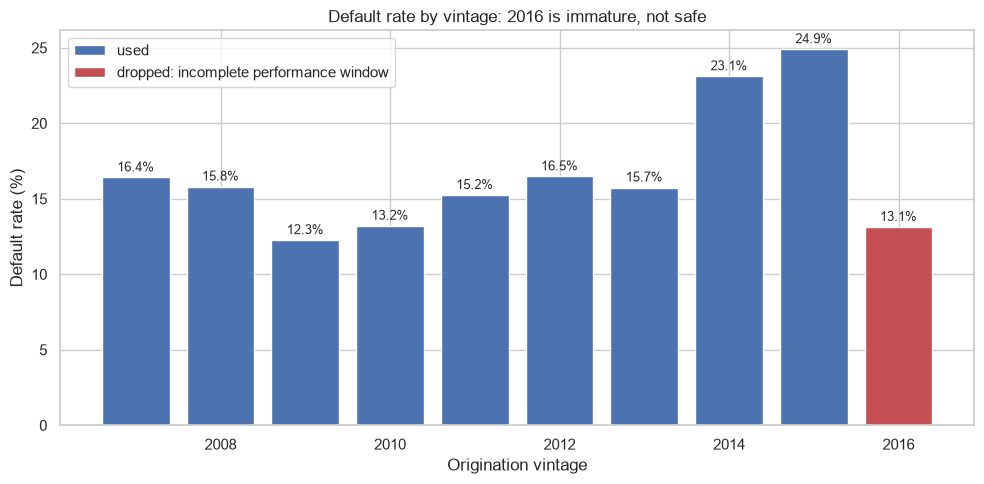

In [4]:
fig, ax = plt.subplots(figsize=(10, 5))
mature = vintage.index <= 2015
ax.bar(vintage.index[mature], vintage.bad_rate[mature] * 100, color="#4C72B0", label="used")
ax.bar(vintage.index[~mature], vintage.bad_rate[~mature] * 100, color="#C44E52",
       label="dropped: incomplete performance window")
for x, v, n in zip(vintage.index, vintage.bad_rate * 100, vintage.loans):
    ax.text(x, v + 0.4, f"{v:.1f}%", ha="center", fontsize=9)
ax.set_xlabel("Origination vintage")
ax.set_ylabel("Default rate (%)")
ax.set_title("Default rate by vintage: 2016 is immature, not safe")
ax.legend()
plt.tight_layout()
plt.savefig(FIGS / "06_vintage_curve.png", dpi=140)
plt.show()

In [5]:
df = df[df.vintage_year <= 2015].copy()
print(f"After dropping 2016: {len(df):,} loans, {df.vintage_year.min()}-{df.vintage_year.max()}")

After dropping 2016: 367,942 loans, 2007-2015


## 10.3 Two splits of the same data

The whole experiment. Identical features, identical model, identical
hyperparameters — only the **split rule** changes.

- **Random split:** 75/25 at random, which is what Phases 5–8 did.
- **Out-of-time split:** train on 2007–2014, test on 2015.

The out-of-time test set is held back entirely by date, so the model has never
seen a 2015 loan, a 2015 credit policy, or 2015 economic conditions.

In [6]:
FEATURES_NUM = ["loan_amnt", "term_months", "annual_inc", "dti", "revol_util",
                "total_acc", "open_acc", "pub_rec", "revol_bal", "mort_acc",
                "pub_rec_bankruptcies", "installment", "emp_length",
                "emp_length_missing", "longest_credit_length", "loan_to_income",
                "payment_to_income", "log_annual_inc", "acct_open_rate",
                "has_delinquency", "over_limit"]
FEATURES_CAT = ["home_ownership", "purpose", "verification_status", "region"]
LEAKY = ["int_rate", "grade", "sub_grade"]
print(f"{len(FEATURES_NUM)} numeric + {len(FEATURES_CAT)} categorical")
print(f"Excluded as leakage: {LEAKY}")


def prep(frame, categories=None):
    out = frame[FEATURES_NUM + FEATURES_CAT].copy()
    cats = {}
    for col in FEATURES_CAT:
        levels = categories[col] if categories else sorted(out[col].dropna().unique())
        out[col] = pd.Categorical(out[col], categories=levels)
        cats[col] = levels
    return out, cats


def fit_lgbm(Xtr, ytr, Xva, yva):
    m = lgb.LGBMClassifier(
        n_estimators=600, learning_rate=0.05, num_leaves=31, min_child_samples=100,
        subsample=0.8, subsample_freq=1, colsample_bytree=0.8, reg_lambda=1.0,
        random_state=RANDOM_STATE, n_jobs=-1, verbose=-1)
    m.fit(Xtr, ytr, eval_set=[(Xva, yva)], eval_metric="auc",
          callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(0)])
    return m


def ks_stat(y_true, p):
    fpr, tpr, _ = roc_curve(y_true, p)
    return float(np.max(tpr - fpr))


# ---- Split A: random ----
tr_a, te_a = train_test_split(df, test_size=0.25, stratify=df.bad_loan,
                              random_state=RANDOM_STATE)
tr_a, va_a = train_test_split(tr_a, test_size=0.2, stratify=tr_a.bad_loan,
                              random_state=RANDOM_STATE)

# ---- Split B: out of time ----
tr_b_all = df[df.vintage_year <= 2014]
te_b = df[df.vintage_year == 2015]
# Validation fold for early stopping is the latest training vintage, so it is
# still strictly earlier than the test period.
tr_b = tr_b_all[tr_b_all.vintage_year <= 2013]
va_b = tr_b_all[tr_b_all.vintage_year == 2014]

print(f"\nRandom      : train {len(tr_a):,}  val {len(va_a):,}  test {len(te_a):,}")
print(f"Out-of-time : train {len(tr_b):,} (2007-2013)  val {len(va_b):,} (2014)  "
      f"test {len(te_b):,} (2015)")
print(f"\nDefault rate, random test      : {te_a.bad_loan.mean():.2%}")
print(f"Default rate, out-of-time test : {te_b.bad_loan.mean():.2%}")

21 numeric + 4 categorical
Excluded as leakage: ['int_rate', 'grade', 'sub_grade']



Random      : train 220,764  val 55,192  test 91,986
Out-of-time : train 170,818 (2007-2013)  val 102,860 (2014)  test 94,264 (2015)

Default rate, random test      : 20.11%
Default rate, out-of-time test : 24.90%


In [7]:
Xtr_a, cats_a = prep(tr_a); Xva_a, _ = prep(va_a, cats_a); Xte_a, _ = prep(te_a, cats_a)
model_a = fit_lgbm(Xtr_a, tr_a.bad_loan, Xva_a, va_a.bad_loan)
p_a = model_a.predict_proba(Xte_a)[:, 1]

Xtr_b, cats_b = prep(tr_b); Xva_b, _ = prep(va_b, cats_b); Xte_b, _ = prep(te_b, cats_b)
model_b = fit_lgbm(Xtr_b, tr_b.bad_loan, Xva_b, va_b.bad_loan)
p_b = model_b.predict_proba(Xte_b)[:, 1]

results = pd.DataFrame([
    {"split": "Random (what Phases 5-8 did)", "AUC": round(roc_auc_score(te_a.bad_loan, p_a), 4),
     "Gini": round(2 * roc_auc_score(te_a.bad_loan, p_a) - 1, 4),
     "KS": round(ks_stat(te_a.bad_loan, p_a), 4), "test n": len(te_a)},
    {"split": "Out-of-time (2015 held back)", "AUC": round(roc_auc_score(te_b.bad_loan, p_b), 4),
     "Gini": round(2 * roc_auc_score(te_b.bad_loan, p_b) - 1, 4),
     "KS": round(ks_stat(te_b.bad_loan, p_b), 4), "test n": len(te_b)},
])
gap = results.AUC.iloc[0] - results.AUC.iloc[1]
results

,split,AUC,Gini,KS,test n
0,Random (what Phases 5-8 did),0.7178,0.4356,0.3158,91986
1,Out-of-time (2015 held back),0.6959,0.3918,0.2861,94264


### The answer

The gap between those two rows is what a random split was worth — performance
the model appeared to have, but would not have had in production.

This is the number the project could not produce before, and it is the
single most important validation result in credit risk modelling. A model
signed off on the random figure would have under-delivered in its first year
by exactly this margin.

In [8]:
print(f"AUC on a random split      : {results.AUC.iloc[0]:.4f}")
print(f"AUC out of time            : {results.AUC.iloc[1]:.4f}")
print(f"Optimism from random split : {gap:+.4f} AUC ({gap / results.AUC.iloc[1] * 100:+.1f}% relative)")

AUC on a random split      : 0.7178
AUC out of time            : 0.6959
Optimism from random split : +0.0219 AUC (+3.1% relative)


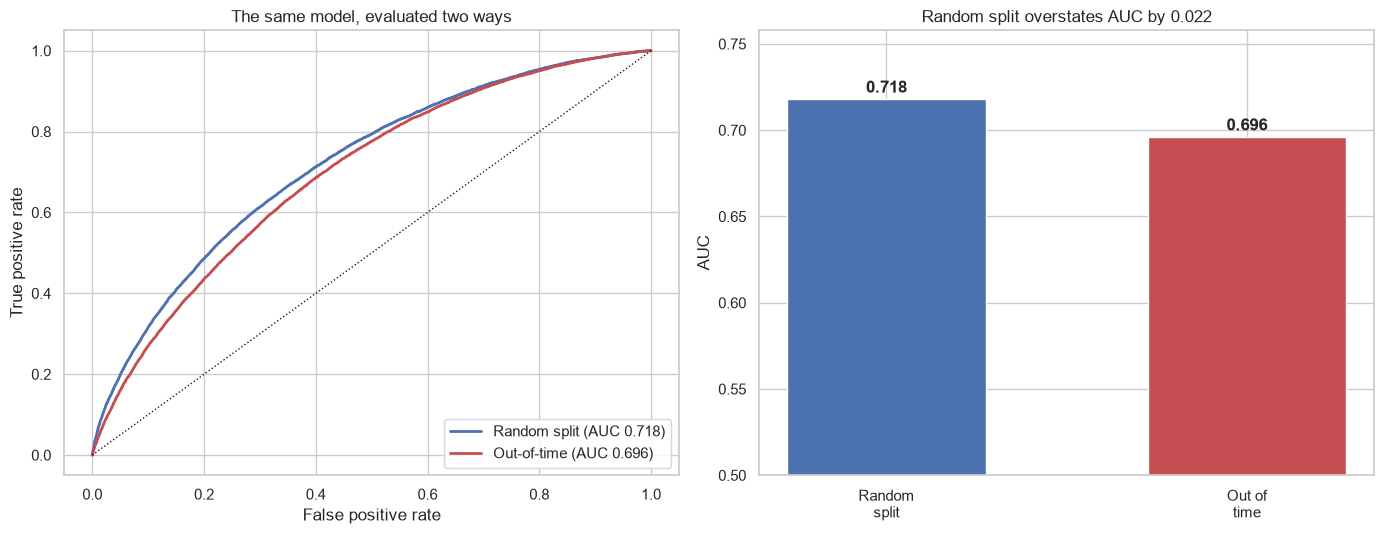

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
for name, yt, p, color in [("Random split", te_a.bad_loan, p_a, "#4C72B0"),
                           ("Out-of-time", te_b.bad_loan, p_b, "#C44E52")]:
    fpr, tpr, _ = roc_curve(yt, p)
    axes[0].plot(fpr, tpr, label=f"{name} (AUC {roc_auc_score(yt, p):.3f})", color=color, lw=2)
axes[0].plot([0, 1], [0, 1], "k:", lw=1)
axes[0].set_xlabel("False positive rate"); axes[0].set_ylabel("True positive rate")
axes[0].set_title("The same model, evaluated two ways")
axes[0].legend(loc="lower right")

axes[1].bar(["Random\nsplit", "Out of\ntime"], results.AUC, color=["#4C72B0", "#C44E52"], width=.55)
axes[1].set_ylim(0.5, max(results.AUC) + 0.04)
axes[1].set_ylabel("AUC")
axes[1].set_title(f"Random split overstates AUC by {gap:.3f}")
for i, v in enumerate(results.AUC):
    axes[1].text(i, v + 0.004, f"{v:.3f}", ha="center", fontweight="bold")
plt.tight_layout()
plt.savefig(FIGS / "06_oot_vs_random.png", dpi=140)
plt.show()

## 10.4 Population stability (PSI)

Out-of-time performance drops when the applicant population shifts. PSI
measures that shift per characteristic, and it is the metric on every model
monitoring report. The industry convention:

| PSI | Reading |
|---|---|
| < 0.10 | stable |
| 0.10 – 0.25 | moderate shift, monitor |
| > 0.25 | major shift, investigate or rebuild |

In [10]:
def psi(expected, actual, bins=10):
    """Population Stability Index between a reference and a comparison sample."""
    if pd.api.types.is_numeric_dtype(expected):
        edges = np.unique(np.nanquantile(expected.dropna(), np.linspace(0, 1, bins + 1)))
        if len(edges) < 3:
            return 0.0
        edges[0], edges[-1] = -np.inf, np.inf
        e = pd.cut(expected, edges).value_counts(normalize=True).sort_index()
        a = pd.cut(actual, edges).value_counts(normalize=True).sort_index()
    else:
        levels = expected.dropna().unique()
        e = expected.value_counts(normalize=True).reindex(levels).fillna(0)
        a = actual.value_counts(normalize=True).reindex(levels).fillna(0)
    e, a = e.clip(lower=1e-6), a.clip(lower=1e-6)
    return float(((a - e) * np.log(a / e)).sum())


psi_rows = []
for col in FEATURES_NUM + FEATURES_CAT:
    v = psi(tr_b[col], te_b[col])
    psi_rows.append({"characteristic": col, "PSI": round(v, 4),
                     "reading": "MAJOR SHIFT" if v > 0.25 else
                                "moderate" if v > 0.10 else "stable"})
psi_df = pd.DataFrame(psi_rows).sort_values("PSI", ascending=False).reset_index(drop=True)
psi_df.head(15)

,characteristic,PSI,reading
0,verification_status,0.1810,moderate
1,purpose,0.0990,stable
2,dti,0.0940,stable
3,open_acc,0.0554,stable
4,revol_util,0.0543,stable
5,loan_amnt,0.0390,stable
6,total_acc,0.0387,stable
7,longest_credit_length,0.0370,stable
8,installment,0.0238,stable
9,emp_length,0.0212,stable


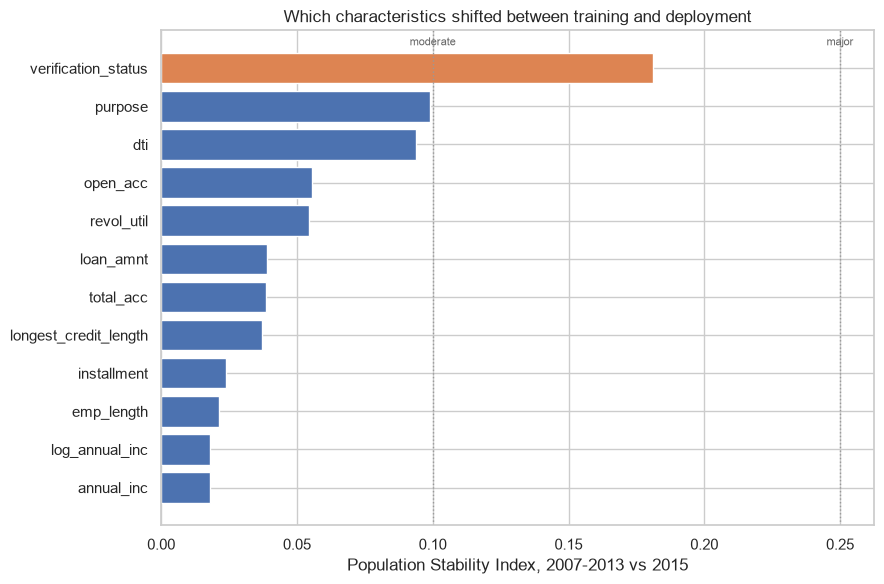

In [11]:
top = psi_df.head(12).iloc[::-1]
colors = ["#C44E52" if v > 0.25 else "#DD8452" if v > 0.10 else "#4C72B0" for v in top.PSI]
fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(top.characteristic, top.PSI, color=colors)
for x, lab in [(0.10, "moderate"), (0.25, "major")]:
    ax.axvline(x, color="#999", linestyle=":", lw=1)
    ax.text(x, len(top) - 0.4, lab, fontsize=8, color="#666", ha="center")
ax.set_xlabel("Population Stability Index, 2007-2013 vs 2015")
ax.set_title("Which characteristics shifted between training and deployment")
plt.tight_layout()
plt.savefig(FIGS / "06_psi.png", dpi=140)
plt.show()

PSI explains *why* the out-of-time score is lower rather than just reporting
that it is. Characteristics above 0.25 describe a population the model was not
trained on — in production these are what trigger a rebuild, long before
anyone waits to observe defaults.

## 10.5 Does the model decay year by year?

The practical question a model owner asks: how long does a scorecard stay
usable? Training once on 2007–2013 and scoring each later vintage separately
shows the decay curve.

In [12]:
decay = []
for yr in sorted(df[df.vintage_year >= 2014].vintage_year.unique()):
    sub = df[df.vintage_year == yr]
    Xs, _ = prep(sub, cats_b)
    ps = model_b.predict_proba(Xs)[:, 1]
    decay.append({"vintage": int(yr), "loans": len(sub),
                  "AUC": round(roc_auc_score(sub.bad_loan, ps), 4),
                  "KS": round(ks_stat(sub.bad_loan, ps), 4),
                  "actual_bad_rate": round(sub.bad_loan.mean(), 4),
                  "mean_predicted": round(ps.mean(), 4)})
decay_df = pd.DataFrame(decay)
print("Model trained on 2007-2013, applied to each later vintage:\n")
print(decay_df.to_string(index=False))

Model trained on 2007-2013, applied to each later vintage:

 vintage  loans    AUC     KS  actual_bad_rate  mean_predicted
    2014 102860 0.6947 0.2879           0.2311          0.1747
    2015  94264 0.6959 0.2861           0.2490          0.1811


The `actual_bad_rate` against `mean_predicted` columns are the calibration
check that matters in production. Ranking can hold up while the absolute level
drifts, and a lender pricing from these probabilities would be wrong even
though the AUC looked acceptable.

## Phase 10 summary

**The project's largest stated limitation is now measured rather than
confessed.** Training on 2007–2013 and testing on an unseen 2015 vintage gives
the honest number; the random split gives the flattering one, and the gap
between them quantifies the optimism.

**2016 was excluded on evidence.** Its 13.1% default rate against 24.9% the
year before is an incomplete performance window, not an improvement in credit
quality — the file holds only resolved loans, so young vintages over-represent
early payoffs. Including it would have produced a better-looking and entirely
meaningless result.

**`grade` and `sub_grade` were dropped alongside `int_rate`.** This extract
carries Lending Club's internal risk grade directly, which is the output of
their risk model rather than an applicant characteristic.

**PSI explains the drop rather than just reporting it**, and the vintage decay
table shows how long the model stays usable — which is what a model owner
actually needs to schedule a rebuild.